### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn import linear_model
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS = [
    'long_hold_no_noise_DC_test_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-07-28_12:06:05.695587_run_000022',
    'long_hold_no_noise_DC_test_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-07-28_11:32:33.088178_run_000021',
]

DATA_PATHS = [ './sims_out/' + d for d in DATA_PATHS]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
def load_numpy(data_path):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

### Analysis of neural activity

In [10]:
def load_r_and_int_values(rule_path, net_path, last_n=100):
    all_r = np.stack(load_numpy(os.path.join(rule_path, 'activities', net_path)))
    all_int_values = np.stack(load_numpy(os.path.join(rule_path, 'integrated_values', net_path)))
    
    if last_n is not None:
        last_n_r = all_r[-last_n:, 200:, :15]
        all_int_values = all_int_values[-last_n:, :]
    else:
        last_n_r = all_r[:, 200:, :15]
        
    last_n_r = np.transpose(last_n_r, [2, 0, 1])

    return last_n_r, all_int_values

Do PCA on last 50 trials, 15 units in ellipsoid body.

In [11]:
def fit_pca(last_100_r):
    flattened_data = last_100_r.reshape(last_100_r.shape[0], last_100_r.shape[1] * last_100_r.shape[2], order='C')
    pca = PCA()
    pc_activities = pca.fit_transform(flattened_data.T)
    pc_activities = pc_activities.T.reshape(last_100_r.shape, order='C')

    return pc_activities, pca

Learned structure leads to low dimensional activity.

In [12]:
def make_tuning_curves(last_100_r, all_int_values, save_name_1=None, save_name_2=None):
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    int_values_for_ending_states = np.empty((all_int_values.shape[0]))
    for i, j in enumerate(np.argsort(all_int_values[:, -250])):
        ending_states[:, i] = last_100_r[:, j, -250]
        int_values_for_ending_states[i] = all_int_values[j, -250]
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    m = np.abs(ending_states).max()
    axs.matshow(ending_states, cmap='bwr', vmin=-m, vmax=m, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum', fontsize=16)
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron', fontsize=16)
    axs.set_yticks([0, 14])
    axs.tick_params(axis='both', length=6, labelsize=16)

    if save_name_1 is not None:
        fig.savefig(save_name_1, bbox_inches='tight')
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(2.3 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    int_min, int_max = int_values_for_ending_states.min(), int_values_for_ending_states.max()
    colors = [cmap((int_values_for_ending_states[i] - int_min) / (int_max - int_min))[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

    norm = matplotlib.colors.Normalize(vmin=int_min, vmax=int_max)
    sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Only needed for older versions of matplotlib
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', pad=0.02)
    cbar.set_label("Integrated value")
    format_plot(cbar.ax)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)', fontsize=16)
    axs.set_xlabel('Neuron', fontsize=16)
    axs.set_xticks([0, 14])
    axs.set_xlim(0, 14)
    axs.tick_params(axis='both', length=6, labelsize=16)

    if save_name_2 is not None:
        fig.savefig(save_name_2, bbox_inches='tight')

In [13]:
from matplotlib import gridspec

def make_stability_plot(last_100_r, all_int_values, save_name=None):
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    scale = 3

    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

    def normed_loc(raster):
        total_activity = raster.sum(axis=0)
        raster_normed = np.divide(
            raster,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster)
        )
        ordered_indices = np.argsort(raster, axis=0)
        max_5_indices = ordered_indices[-13:, :]
        x = np.arange(raster_normed.shape[0])
        cols = np.arange(raster.shape[1])[None, :]
        locs = np.einsum(
            'ij,ij->j',
            x[max_5_indices],
            raster_normed[max_5_indices, cols],
        )
        return locs

    all_final_traj = []

    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(2.5 * scale, 1 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

    sorted_int_values = []

    # Use global color normalization for consistent coloring
    global_max = np.max(np.abs(all_int_values))
    norm = matplotlib.colors.Normalize(vmin=-global_max, vmax=global_max)

    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        traj = normed_loc(last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        cbar = ax_main.plot(
            np.arange(all_int_values.shape[1]),
            traj,
            alpha=0.5,
            color=cmap(norm(all_int_values[j, -1])),
        )
        
        sorted_int_values.append(all_int_values[j, :])

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)', fontsize=16)
    ax_main.set_ylabel('Bump location', fontsize=16)
    ax_main.set_xticks(np.arange(0, 1301, 1000))
    ax_main.set_xticklabels((np.arange(0, 1301, 1000) / 10).astype(int))
    ax_main.set_yticks([0, 15], [0, 15])
    ax_main.set_ylim(-1, 16)
    ax_main.set_xlim(0)
    ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main, ticklabelsize=16, axislabelsize=16)

    # Histogram on the right (rotated)
    ax_hist.hist(all_final_traj, bins=30, orientation='horizontal', color='gray')
    ax_hist.set_xlabel('Count', fontsize=16)
    ax_hist.tick_params(axis='x', labelsize=14)
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-axis labels to avoid duplication
    format_plot(ax_hist, ticklabelsize=16, axislabelsize=16)

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

    plt.show()

    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))

    # axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(np.stack(sorted_int_values)[:, -1], all_final_traj, s=30, zorder=1, facecolor='red', edgecolor='red', alpha=0.2)
    # axs.set_xlim(-m, m)
    # axs.set_ylim(-m, m)
    # axs.set_xticks([-100, 0, 100])
    # axs.set_yticks([-100, 0, 100])
    
    format_plot(axs)

    axs.set_xlabel(r'$y$', fontsize=16)
    axs.set_ylabel(r'Bump location', fontsize=16)
    # axs.set_title('Predicted vs true integrated sums', fontsize=16)
    axs.tick_params(axis='both', length=6, labelsize=16)
    

In [14]:
for dp in DATA_PATHS[:1]:
    for i in range(10):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=100)
        make_tuning_curves(
            last_100_r,
            all_int_values,
            save_name_1=f'./figures/ordered_states_{i}.svg',
            save_name_2=f'./figures/tuning_curve_{i}.svg',
        )
        make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/stability_plot_{i}.svg')

ValueError: need at least one array to stack

In [7]:
import matplotlib.cm as cm
import matplotlib.colors as colors
import math

def make_tuning_curve_grid(last_100_r_all, all_int_values_all, labels=None, ncols=5):
    """
    Plot tuning curves for a series of networks in a rectangular grid (e.g., 5x4).
    
    Parameters
    ----------
    last_100_r_all : ndarray
        Shape (n_networks, n_neurons, n_trials, time)
    all_int_values_all : ndarray
        Shape (n_networks, n_trials, time)
    ncols : int
        Number of columns in the subplot grid
    """
    n_networks = last_100_r_all.shape[0]
    n_neurons = last_100_r_all.shape[1]
    nrows = math.ceil(n_networks / ncols)

    fig, axs = plt.subplots(nrows, ncols, figsize=(1.8 * ncols, 1.2 * nrows), sharex=True, sharey=True)
    axs = np.array(axs).reshape(-1)  # flatten in case of 1D row or column

    plasma = cm.get_cmap("plasma")

    # Use global color normalization for consistent coloring
    global_min = np.min(all_int_values_all[:, :, -250])
    global_max = np.max(all_int_values_all[:, :, -250])
    norm = colors.Normalize(vmin=global_min, vmax=global_max)

    for net_idx in range(n_networks):
        ax = axs[net_idx]
        last_100_r = last_100_r_all[net_idx]
        all_int_values = all_int_values_all[net_idx]

        sort_idx = np.argsort(all_int_values[:, -250])
        sorted_int_values = all_int_values[sort_idx, -250]
        sorted_activity = last_100_r[:, sort_idx, -250]

        color_vals = [plasma(norm(val))[:3] for val in sorted_int_values]

        for trial in range(sorted_activity.shape[1]):
            ax.plot(np.arange(n_neurons), sorted_activity[:, trial], color=color_vals[trial], lw=1)

        ax.set_xlim(0, n_neurons - 1)
        ax.tick_params(axis='both', labelsize=8, length=3)

        if labels is not None:
            ax.text(0.05, 1.2, labels[net_idx], transform=ax.transAxes, fontsize=8, va='top', ha='left', color='black')

    axs[0].set_ylabel("Firing rate (Hz)")
    axs[ncols * (nrows - 1)].set_xlabel("Neuron")

    # Hide unused subplots if n_networks < nrows * ncols
    for idx in range(n_networks, nrows * ncols):
        axs[idx].axis("off")

    # Add horizontal colorbar at top
    sm = cm.ScalarMappable(cmap=plasma, norm=norm)
    sm.set_array([])
    fig.subplots_adjust(top=0.88)
    cbar_ax = fig.add_axes([0.1, 0.99, 0.3, 0.015])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Integrated value", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    format_plot(axs)
    format_plot(cbar_ax)

    fig.tight_layout(rect=[0, 0, 1, 0.88])
    return fig, axs

In [8]:
all_r_stack = []
int_values_stack = []
for dp in DATA_PATHS:
    for i in range(2,3):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        all_r_stack.append(all_r)
        int_values_stack.append(all_int_values)
all_r_stack = np.stack(all_r_stack)
int_values_stack = np.stack(int_values_stack)

/tmp/ipykernel_1762030/453206794.py:25: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



[<Axes: ylabel='Firing rate (Hz)'> <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: xlabel='Neuron'> <Axes: > <Axes: > <Axes: > <Axes: >]
Axes(0.1,0.99;0.3x0.015)


/tmp/ipykernel_1762030/453206794.py:71: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



(<Figure size 900x600 with 26 Axes>,
 array([<Axes: ylabel='Firing rate (Hz)'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Neuron'>,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

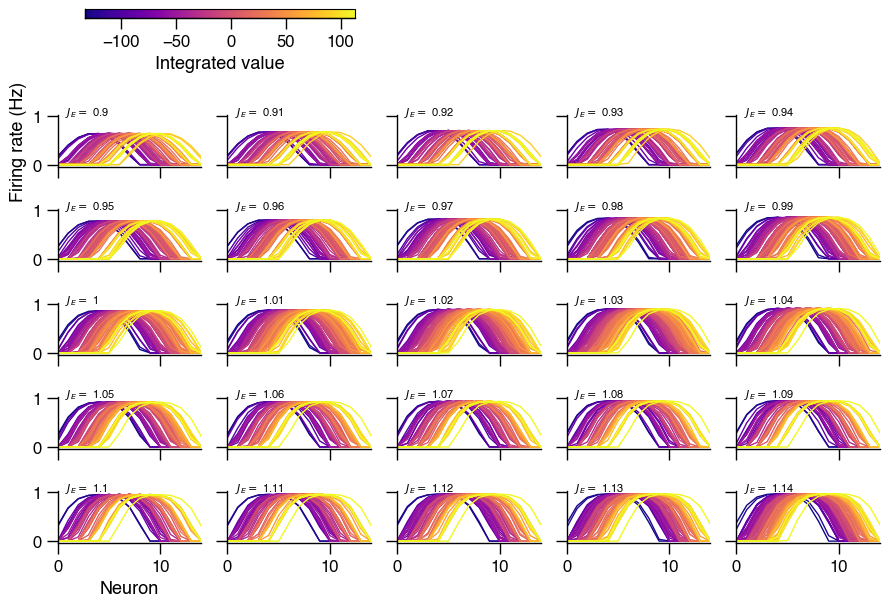

In [9]:
make_tuning_curve_grid(
    all_r_stack[:25, ...],
    int_values_stack[:25, ...],
    labels=[(r'$J_E =$ ' + f'{x:.3g}') for x in (np.arange(25) * 0.01 + 0.9)],
)

In [10]:
from scipy.stats import gaussian_kde

def test_representation_fidelity(all_r, all_int_values, n_fold=20, lasso_alpha=0.1):

    train_range = slice(0, 40)
    test_range = slice(40, 140)
    
    stacked_activities_train = all_r[:, train_range, :]
    y_train = all_int_values[train_range, :]
    stacked_activities_test = all_r[:, test_range, :]
    y_test = all_int_values[test_range, :]
    
    scores = []
    
    for i in range(n_fold):
        train_acts = np.random.randint(0, 40, size=8000)
        train_steps = np.random.randint(0, 2250, size=8000)
        test_acts = np.arange(100)
        test_steps = np.random.randint(0, 2250, size=100)
        
        X_train = stacked_activities_train[:, train_acts, train_steps + 50].T
        Y_train = y_train[train_acts, train_steps]

        kde = gaussian_kde(Y_train)
        
        X_test = stacked_activities_test[:, test_acts, test_steps + 50].T
        Y_test = y_test[test_acts, test_steps]
        
        reg = linear_model.Lasso(alpha=lasso_alpha).fit(X_train, Y_train, sample_weight=1 / kde(Y_train))
        score = reg.score(X_test, Y_test)
        scores.append(score)
    
    print(scores)
    print(np.mean(scores))

    scale = 0.8
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

    Y_hat = reg.predict(X_test)

    m = 1.05 * np.max(np.abs(np.concatenate([Y_test, Y_hat])))
    
    axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(Y_test, Y_hat, s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
    axs.set_xlim(-m, m)
    axs.set_ylim(-m, m)
    axs.set_xticks([-100, 0, 100])
    axs.set_yticks([-100, 0, 100])
    
    format_plot(axs)
    
    axs.set_xlabel(r'$y$', fontsize=16)
    axs.set_ylabel(r'$\hat{y}$', fontsize=16)
    axs.set_title('Predicted vs true integrated sums', fontsize=16)
    axs.tick_params(axis='both', length=6, labelsize=16)

    return np.mean(scores)

[0.8790517986587771, 0.8495851435815192, 0.8269454924897865, 0.888348063621294, 0.8757782186113785, 0.8742824166844049, 0.8308333760398946, 0.8582165511104898, 0.8566776025331443, 0.8448485933857075, 0.8367365641758899, 0.8768552122451733, 0.887463233382741, 0.8650853623736339, 0.8810786328754455, 0.8662440695697782, 0.8748214981692453, 0.8418252988119456, 0.8843165311511966, 0.8377817052522477]
0.8618387682361848
Axes(0.125,0.11;0.775x0.77)
[0.856748256670972, 0.8726617664125382, 0.8699534333864044, 0.8810275571714723, 0.8767165617694551, 0.8663927202247061, 0.8874163396167243, 0.8700226530354183, 0.8635942451384002, 0.8915975854152383, 0.8718294780429814, 0.8760132026930182, 0.8713237966352523, 0.8566914571950558, 0.8560502202944562, 0.8645945556559248, 0.8628562777899117, 0.8353689309658185, 0.863662446825779, 0.846664151768914]
0.8670592818354219
Axes(0.125,0.11;0.775x0.77)
[0.8802204119131778, 0.9026053819279455, 0.822289095123406, 0.8597975429508926, 0.8528336644424196, 0.8895361

/tmp/ipykernel_1762030/1135425872.py:37: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



[0.8738112715784385, 0.8942638057707067, 0.9172212408426319, 0.9065706258871313, 0.9157299393389129, 0.9100117563220047, 0.9046063987049595, 0.9149159137760129, 0.913600748587699, 0.9011970159563298, 0.8995333164652359, 0.8984992786056423, 0.9012230556256947, 0.9008361143133351, 0.9125555517805198, 0.8947771292765979, 0.8839967040677977, 0.9117628554106125, 0.9085293399121019, 0.9143250926895167]
0.9038983577455941
Axes(0.125,0.11;0.775x0.77)
[0.9010335476008365, 0.9069056254494177, 0.9211665518567292, 0.9038306143638303, 0.9130655553403669, 0.8784552305140512, 0.9018850128988023, 0.9073099968018492, 0.9048164534781318, 0.9137384279011839, 0.9178209484430091, 0.9032977215073377, 0.9242599537138825, 0.908263556992496, 0.908420110183793, 0.9035095269058503, 0.9120124228075553, 0.9071975214058688, 0.9082135736705154, 0.9205822525121222]
0.9082892302173814
Axes(0.125,0.11;0.775x0.77)
[0.9235103473360695, 0.9041077724535622, 0.9231653139998951, 0.9204235697051564, 0.9094810863405913, 0.9217

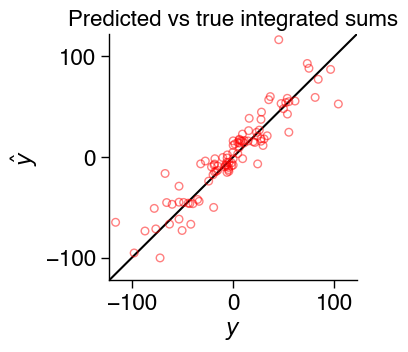

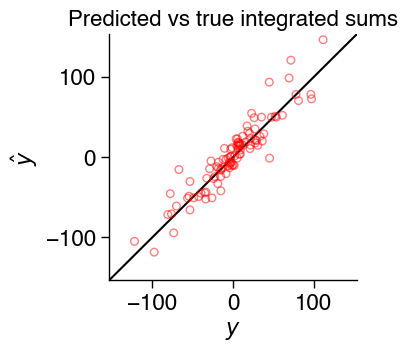

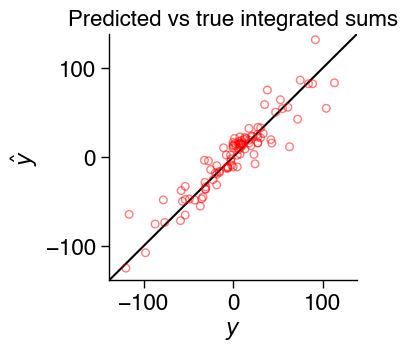

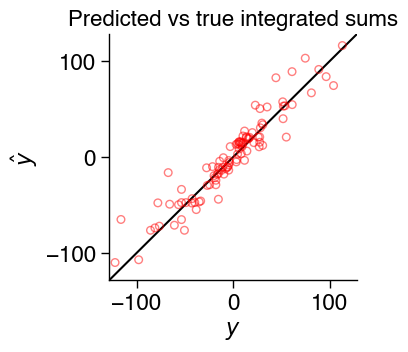

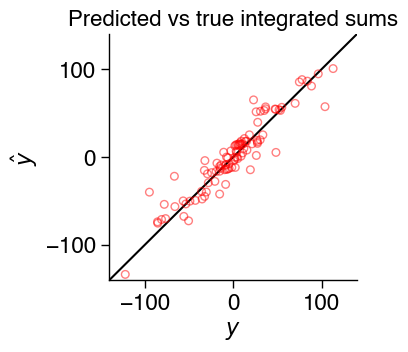

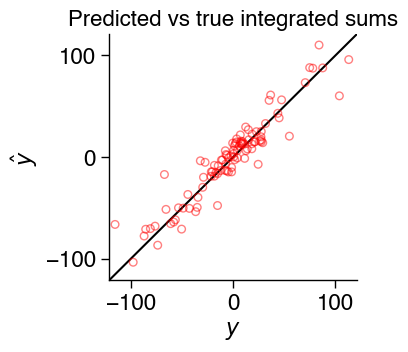

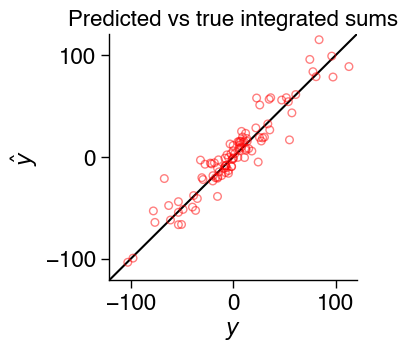

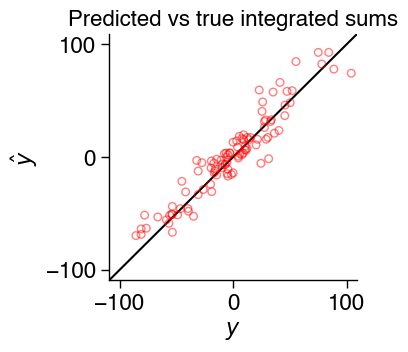

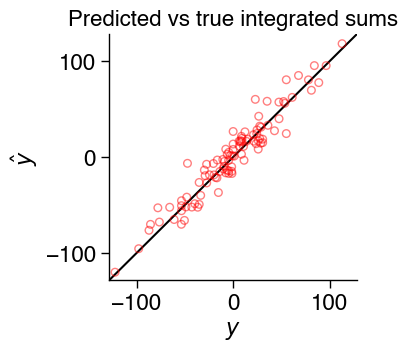

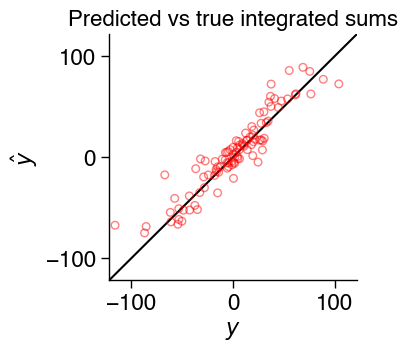

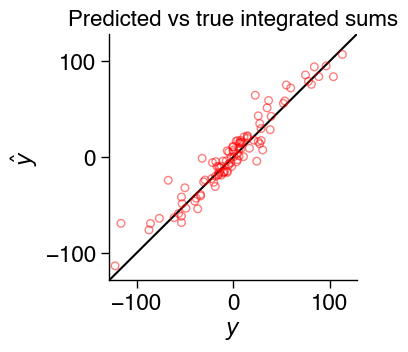

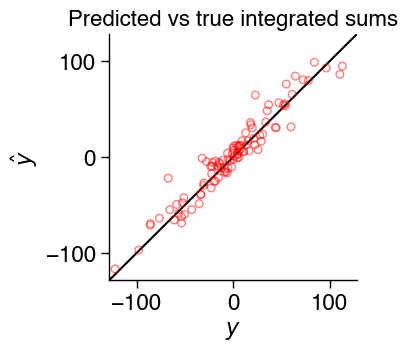

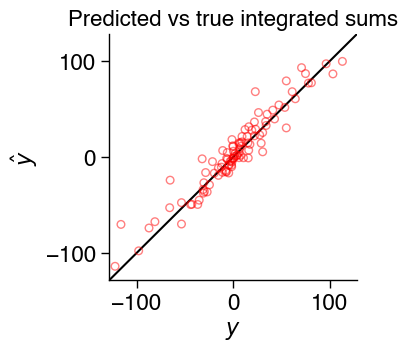

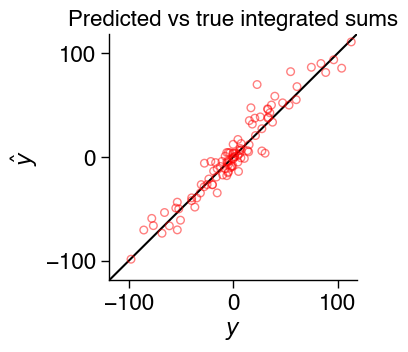

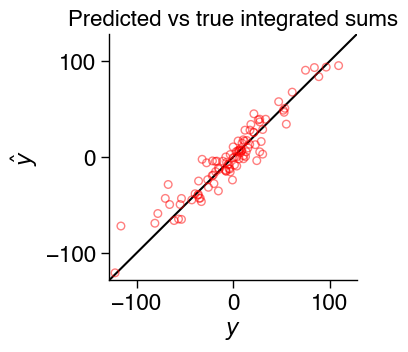

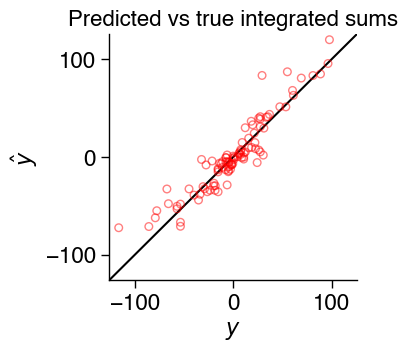

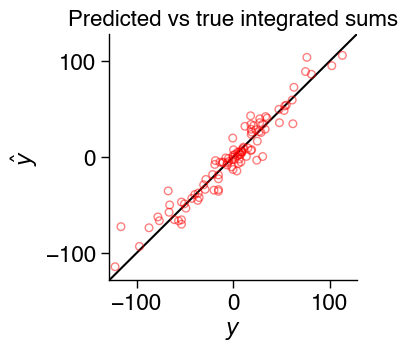

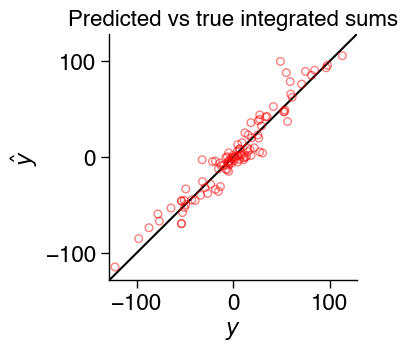

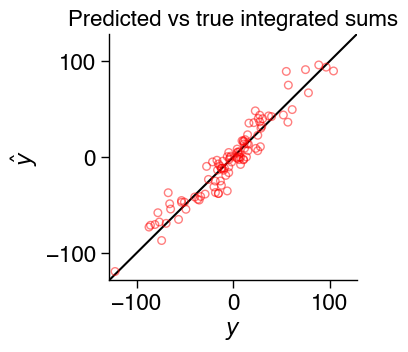

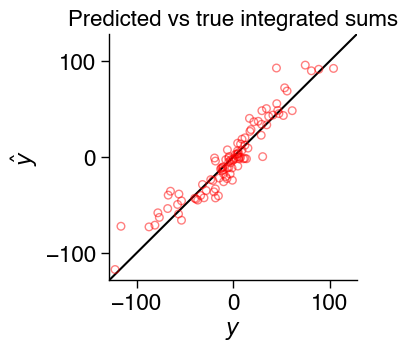

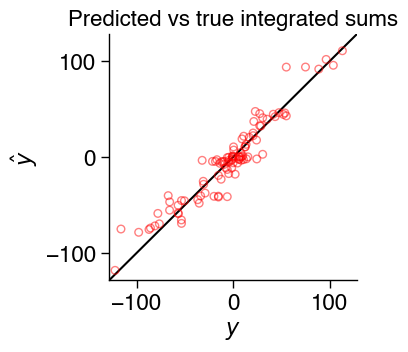

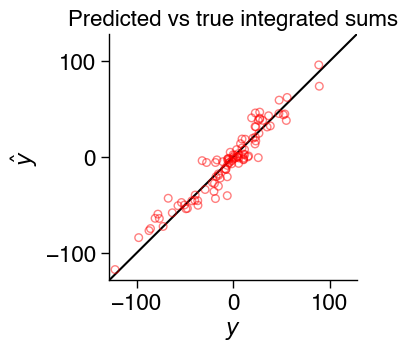

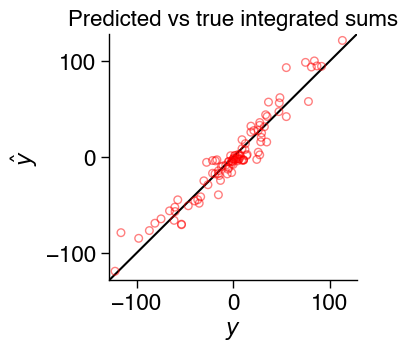

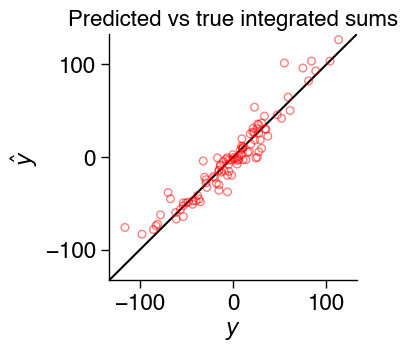

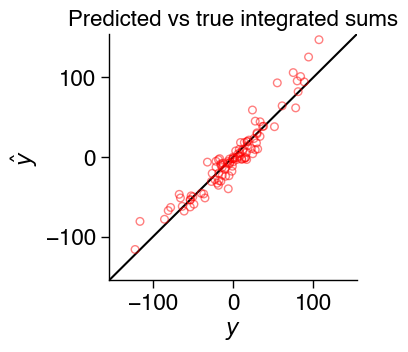

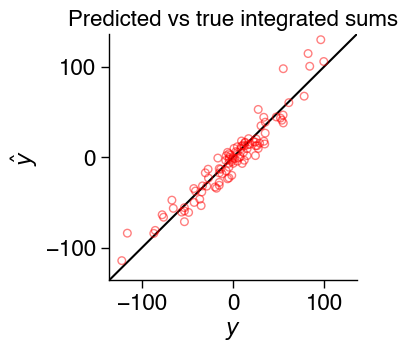

In [11]:
all_scores = []
for dp in DATA_PATHS:
    for i in range(2,3):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        score = test_representation_fidelity(all_r, all_int_values)
        all_scores.append(score)

26
Axes(0.125,0.11;0.775x0.77)


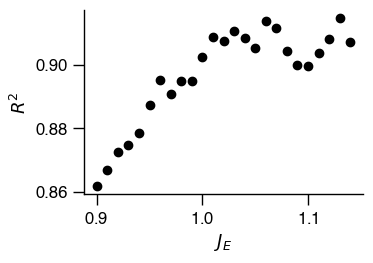

In [12]:
scale = 0.6
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

print(len(all_scores))

axs.scatter(np.arange(25) * 0.01 + 0.9, all_scores[:25], c='black')
axs
axs.set_ylabel(r'$R^2$')
axs.set_xlabel(r'$J_E$')

axs.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))
axs.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

format_plot(axs)

[0.7247022724965294, 0.7394988736493018, 0.7220314324957593]
0.72874419288053
Axes(0.125,0.11;0.775x0.77)
[0.7146603409710366, 0.710686251707394, 0.7026006993307768]
0.7093157640030691
Axes(0.125,0.11;0.775x0.77)
[0.7008833204442264, 0.7795626159692558, 0.7812493497868407]
0.753898428733441
Axes(0.125,0.11;0.775x0.77)
[0.7121744904726129, 0.6820741327588979, 0.736579817948789]
0.7102761470601
Axes(0.125,0.11;0.775x0.77)
[0.7183265940687082, 0.7761285803742314, 0.7606738473484415]
0.7517096739304603
Axes(0.125,0.11;0.775x0.77)
[0.7703694952067676, 0.7349292061569832, 0.7139814627817674]
0.7397600547151728
Axes(0.125,0.11;0.775x0.77)
[0.7919995748758293, 0.7654147757382012, 0.7812735203309198]
0.7795626236483167
Axes(0.125,0.11;0.775x0.77)
[0.6992028713708727, 0.7846511497815741, 0.7898606569916788]
0.7579048927147086
Axes(0.125,0.11;0.775x0.77)
[0.7064891546488465, 0.709372059687067, 0.7662466199670211]
0.7273692781009782
Axes(0.125,0.11;0.775x0.77)
[0.7563770491995989, 0.73960051836451

/tmp/ipykernel_1009104/1135425872.py:37: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



[0.8651462224929695, 0.8412610921846172, 0.8289612693285869]
0.8451228613353913
Axes(0.125,0.11;0.775x0.77)
[0.8528150051771667, 0.8272384573920295, 0.8421556345050369]
0.8407363656914111
Axes(0.125,0.11;0.775x0.77)
[0.825999692061938, 0.8456154515605467, 0.8381790431957968]
0.8365980622727606
Axes(0.125,0.11;0.775x0.77)
[0.819596628689065, 0.8430351567048219, 0.8486352296204711]
0.837089005004786
Axes(0.125,0.11;0.775x0.77)
[0.8647312928718784, 0.8396831983713582, 0.8603483040610191]
0.8549209317680853
Axes(0.125,0.11;0.775x0.77)


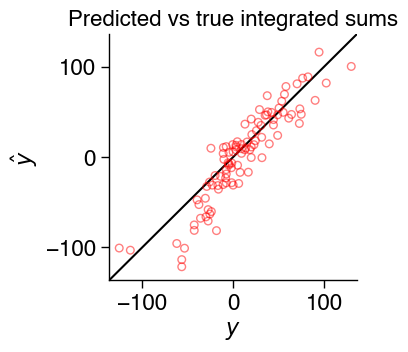

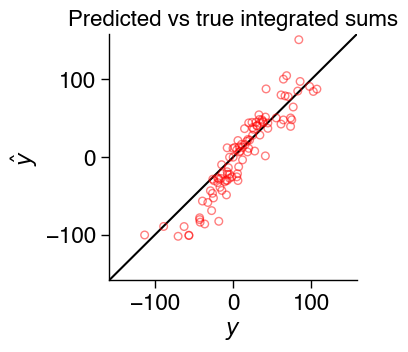

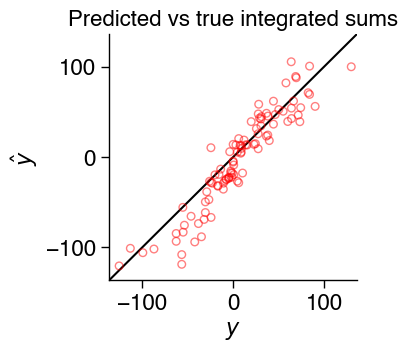

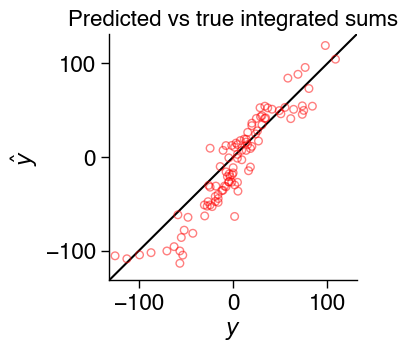

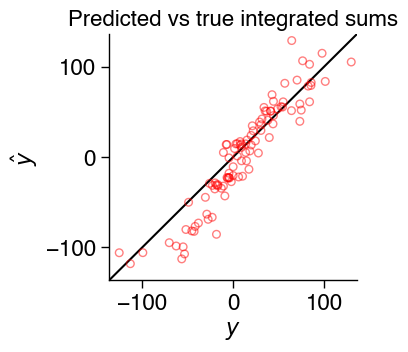

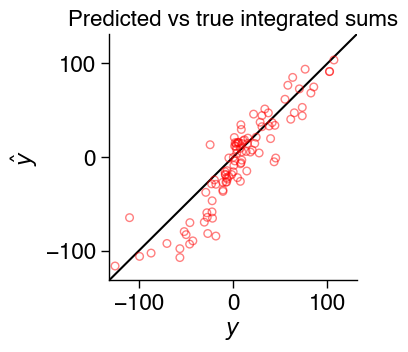

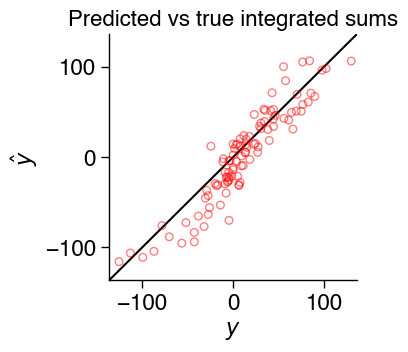

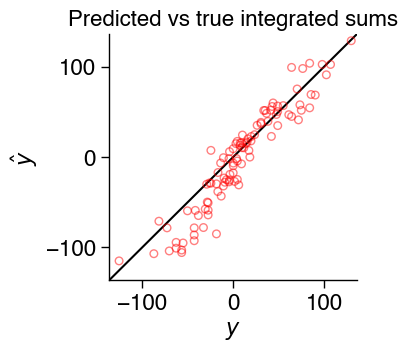

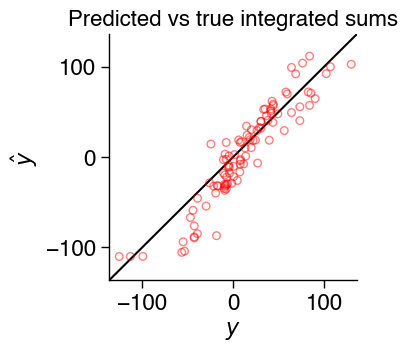

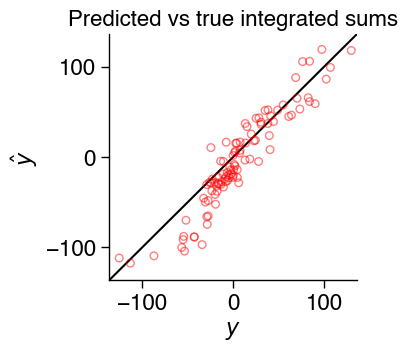

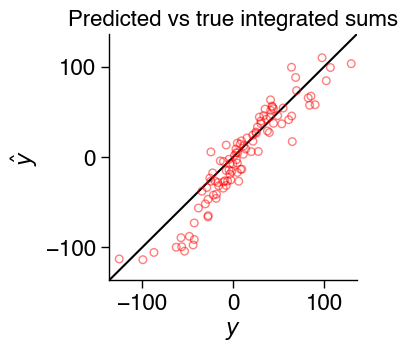

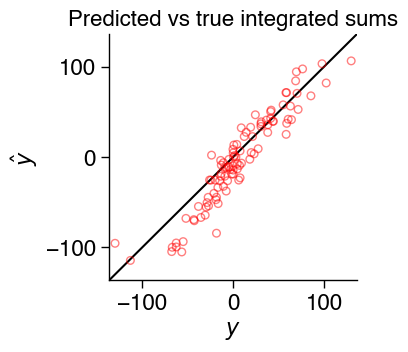

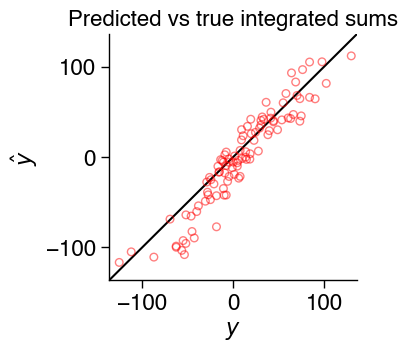

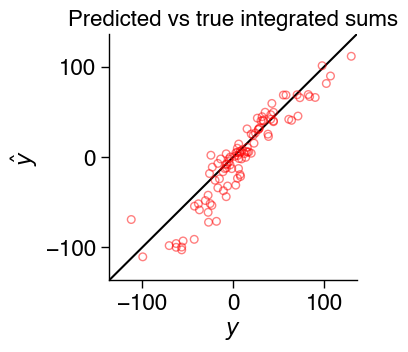

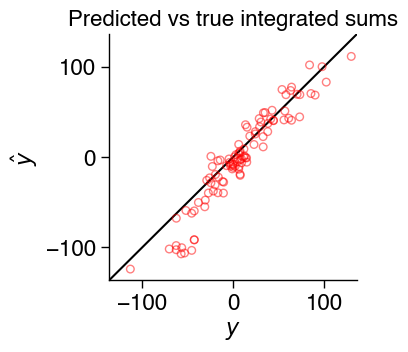

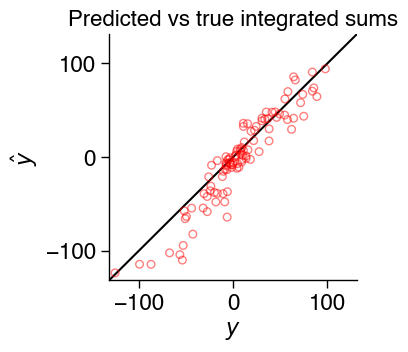

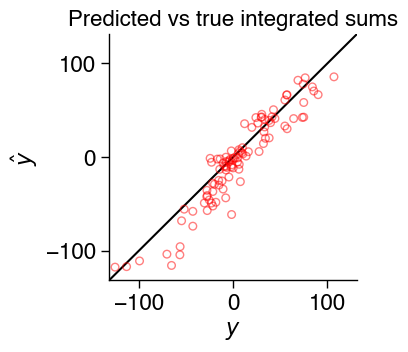

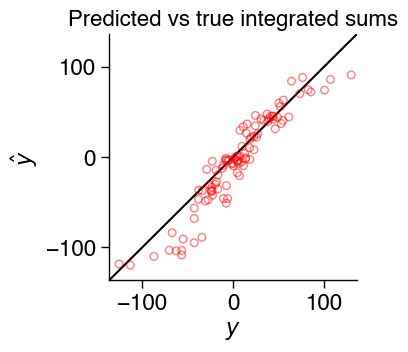

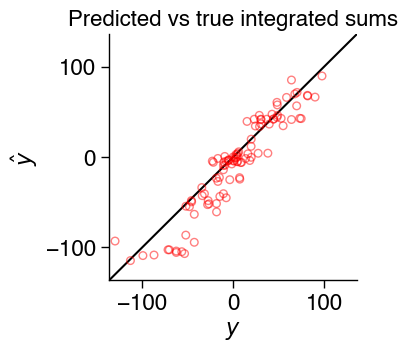

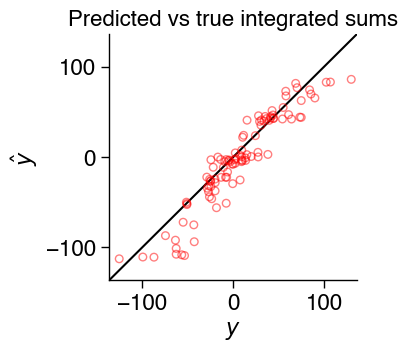

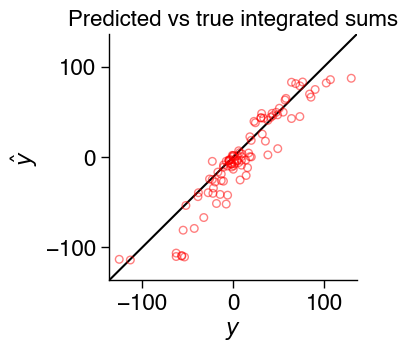

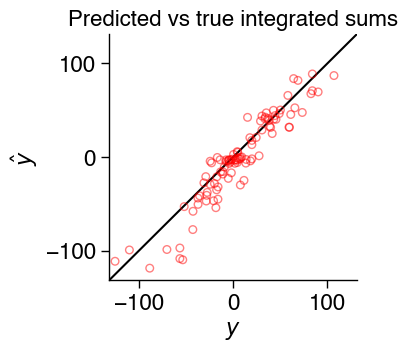

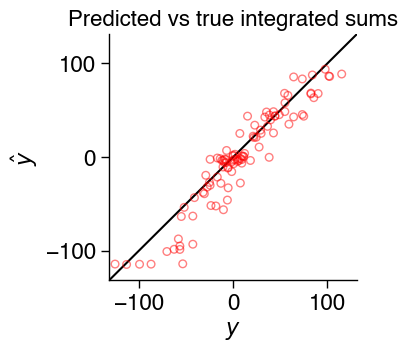

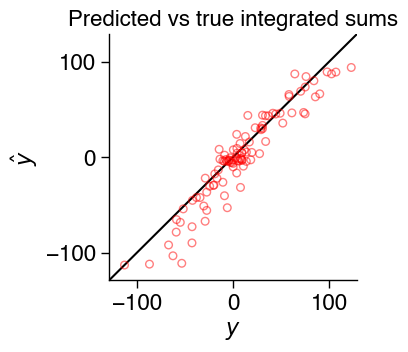

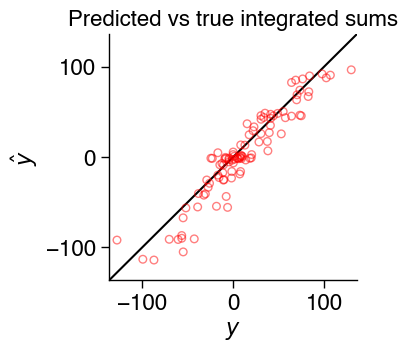

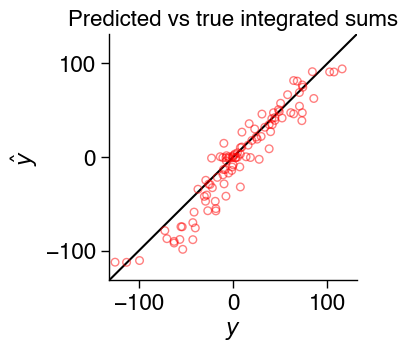

In [11]:
all_scores_prime = []
for dp in DATA_PATHS:
    for i in range(1, 2):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        score = test_representation_fidelity(all_r, all_int_values, n_fold=3, lasso_alpha=0.05)
        all_scores_prime.append(score)

26
Axes(0.125,0.11;0.775x0.77)


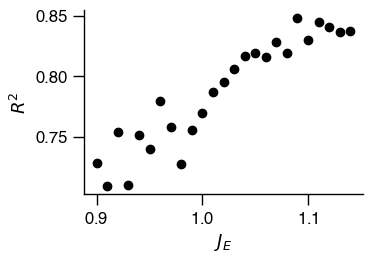

In [12]:
scale = 0.6
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

print(len(all_scores_prime))

axs.scatter(np.arange(25) * 0.01 + 0.9, all_scores_prime[:25], c='black')
axs
axs.set_ylabel(r'$R^2$')
axs.set_xlabel(r'$J_E$')

axs.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))
axs.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

format_plot(axs)